In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

PROJECT_ROOT = Path.cwd().parent
CLEAN = PROJECT_ROOT / 'data' / 'cleaned'
FIG_DIR = PROJECT_ROOT / 'results' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

cme = pd.read_parquet(CLEAN / 'cme_options_clean.parquet')
der = pd.read_parquet(CLEAN / 'deribit_options_clean.parquet')
aux = pd.read_parquet(CLEAN / 'auxiliary_panel.parquet')

# Funding differential may not exist yet if HL scrape is still running
funding_path = CLEAN / 'funding_diff.parquet'
funding = pd.read_parquet(funding_path) if funding_path.exists() else None

print(f"CME:       {len(cme):>10,} rows, {cme['date'].nunique()} days")
print(f"Deribit:   {len(der):>10,} rows, {der['date'].nunique()} days")
print(f"Auxiliary: {len(aux):>10,} rows, {aux['date'].nunique()} days")
if funding is not None:
    print(f"Funding:   {len(funding):>10,} rows, {funding['date'].nunique()} days")

CME:           65,598 rows, 802 days
Deribit:      327,202 rows, 3105 days
Auxiliary:      2,191 rows, 2191 days
Funding:           31 rows, 31 days


#### 1. Cross-Venue Comparison: Daily Option Counts

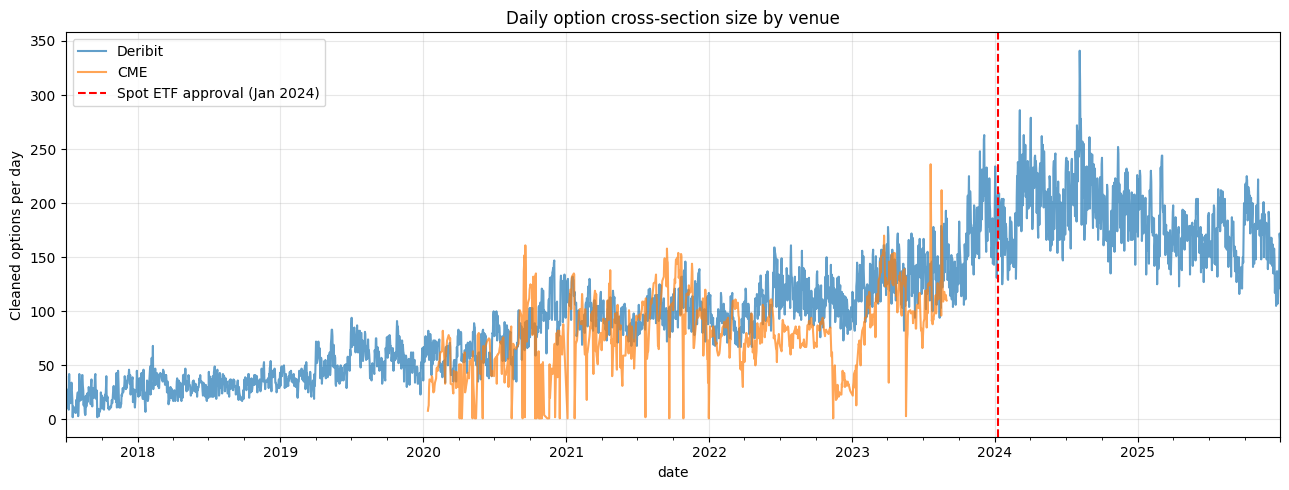

Median per day:
  CME:         82
  Deribit:    100


In [3]:
daily_cme = cme.groupby('date').size().rename('CME')
daily_der = der.groupby('date').size().rename('Deribit')

fig, ax = plt.subplots(figsize=(13, 5))
daily_der.plot(ax=ax, label='Deribit', alpha=0.7)
daily_cme.plot(ax=ax, label='CME', alpha=0.7)
ax.axvline(pd.Timestamp('2024-01-10'), color='red', linestyle='--',
           label='Spot ETF approval (Jan 2024)')
ax.set_ylabel('Cleaned options per day')
ax.set_title('Daily option cross-section size by venue')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_daily_option_counts.png', dpi=150)
plt.show()

print("Median per day:")
print(f"  CME:     {daily_cme.median():>6.0f}")
print(f"  Deribit: {daily_der.median():>6.0f}")

#### 2. ATM Implied Volatility Time Series (Thesis Figure 1)

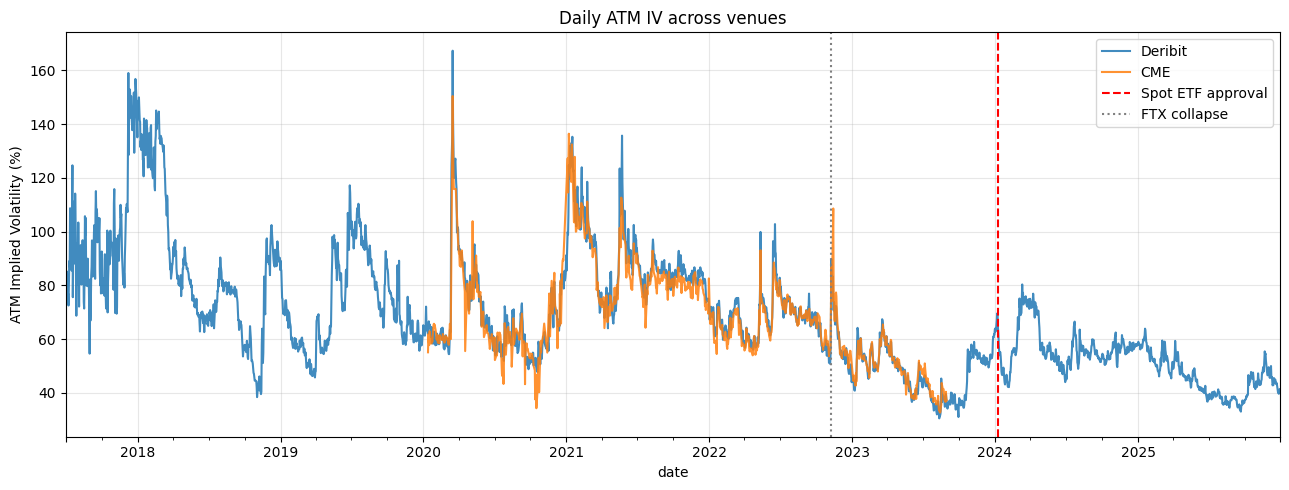

In [4]:
def atm_iv_series(df, venue_label):
    """
    Extract daily ATM IV: for each (date, expiration), pick the strike
    closest to the forward, then average across expirations.
    """
    df = df.copy()
    df['abs_kappa'] = df['log_moneyness'].abs()
    # Closest-to-ATM option per (date, expiration)
    idx = df.groupby(['date', 'expiration'])['abs_kappa'].idxmin()
    atm = df.loc[idx]
    # Average across expirations per day
    return atm.groupby('date')['impliedvolatility'].mean()

atm_cme = atm_iv_series(cme, 'CME')
atm_der = atm_iv_series(der, 'Deribit')

fig, ax = plt.subplots(figsize=(13, 5))
(atm_der * 100).plot(ax=ax, label='Deribit', alpha=0.85)
(atm_cme * 100).plot(ax=ax, label='CME', alpha=0.85)
ax.axvline(pd.Timestamp('2024-01-10'), color='red', linestyle='--',
           label='Spot ETF approval')
ax.axvline(pd.Timestamp('2022-11-08'), color='gray', linestyle=':',
           label='FTX collapse')
ax.set_ylabel('ATM Implied Volatility (%)')
ax.set_title('Daily ATM IV across venues')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_atm_iv_timeseries.png', dpi=150)
plt.show()

#### 3. Slice Density Diagnostics (Critical for SSVI)

In [5]:
def slice_diagnostics(df, name):
    per_slice = df.groupby(['date', 'expiration']).size().reset_index(name='n')
    print(f"\n=== {name} slice density ===")
    print(per_slice['n'].describe())
    print(f"Slices with < 4 options: {(per_slice['n'] < 4).sum():,} "
          f"({(per_slice['n'] < 4).mean():.1%})")
    print(f"Slices with < 3 options: {(per_slice['n'] < 3).sum():,} "
          f"({(per_slice['n'] < 3).mean():.1%})")
    return per_slice

slices_cme = slice_diagnostics(cme, 'CME')
slices_der = slice_diagnostics(der, 'Deribit')


=== CME slice density ===
count    2804.000000
mean       23.394437
std        17.850788
min         1.000000
25%         9.000000
50%        21.000000
75%        34.000000
max       148.000000
Name: n, dtype: float64
Slices with < 4 options: 353 (12.6%)
Slices with < 3 options: 283 (10.1%)

=== Deribit slice density ===
count    13490.000000
mean        24.255152
std         11.012241
min          1.000000
25%         16.000000
50%         22.000000
75%         30.000000
max         70.000000
Name: n, dtype: float64
Slices with < 4 options: 44 (0.3%)
Slices with < 3 options: 26 (0.2%)


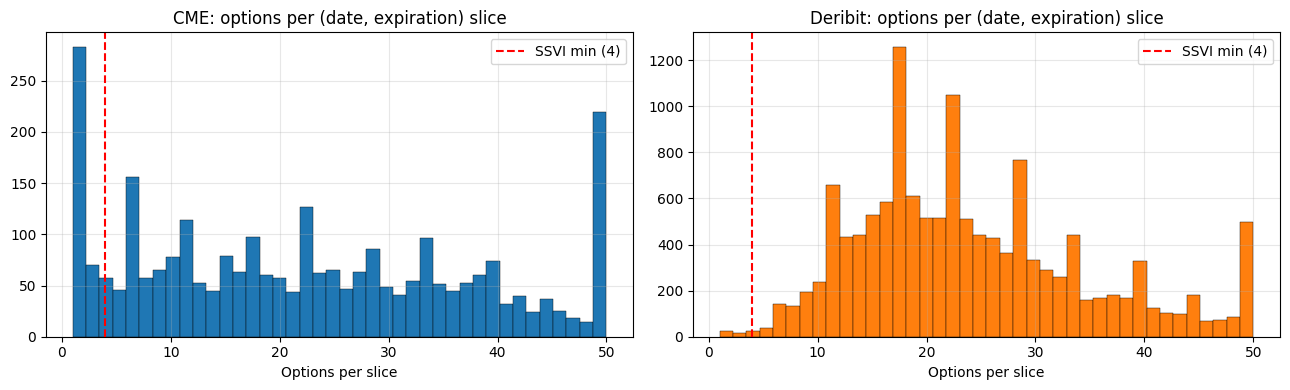

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(slices_cme['n'].clip(upper=50), bins=40, color='C0', edgecolor='black', linewidth=0.3)
axes[0].axvline(4, color='red', linestyle='--', label='SSVI min (4)')
axes[0].set_title('CME: options per (date, expiration) slice')
axes[0].set_xlabel('Options per slice')
axes[0].legend()

axes[1].hist(slices_der['n'].clip(upper=50), bins=40, color='C1', edgecolor='black', linewidth=0.3)
axes[1].axvline(4, color='red', linestyle='--', label='SSVI min (4)')
axes[1].set_title('Deribit: options per (date, expiration) slice')
axes[1].set_xlabel('Options per slice')
axes[1].legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_slice_density.png', dpi=150)
plt.show()

#### 4. Moneyness Coverage by Venue

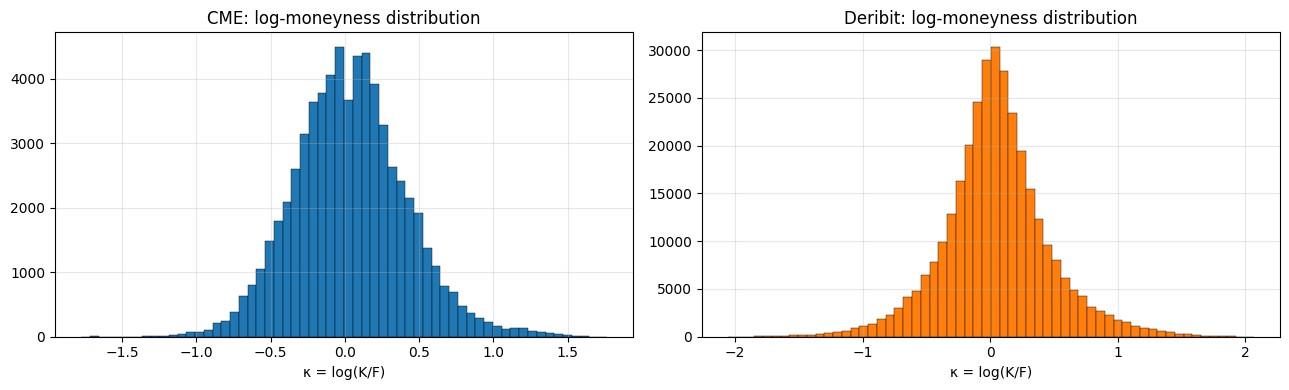

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(cme['log_moneyness'], bins=60, color='C0', edgecolor='black', linewidth=0.3)
axes[0].set_title('CME: log-moneyness distribution')
axes[0].set_xlabel('κ = log(K/F)')

axes[1].hist(der['log_moneyness'], bins=60, color='C1', edgecolor='black', linewidth=0.3)
axes[1].set_title('Deribit: log-moneyness distribution')
axes[1].set_xlabel('κ = log(K/F)')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_moneyness_coverage.png', dpi=150)
plt.show()

#### 5. Auxiliary Panel: Conditioning Variables

In [8]:
print("Auxiliary panel missing-value summary:")
print(aux.isna().sum())
print(f"\nDVOL first valid date: {aux.dropna(subset=['dvol'])['date'].min().date()}")
print(f"DVOL last valid date:  {aux.dropna(subset=['dvol'])['date'].max().date()}")

Auxiliary panel missing-value summary:
date          0
btc_spot      0
rv            0
vix           0
dvol        461
dtype: int64

DVOL first valid date: 2021-04-06
DVOL last valid date:  2025-12-30


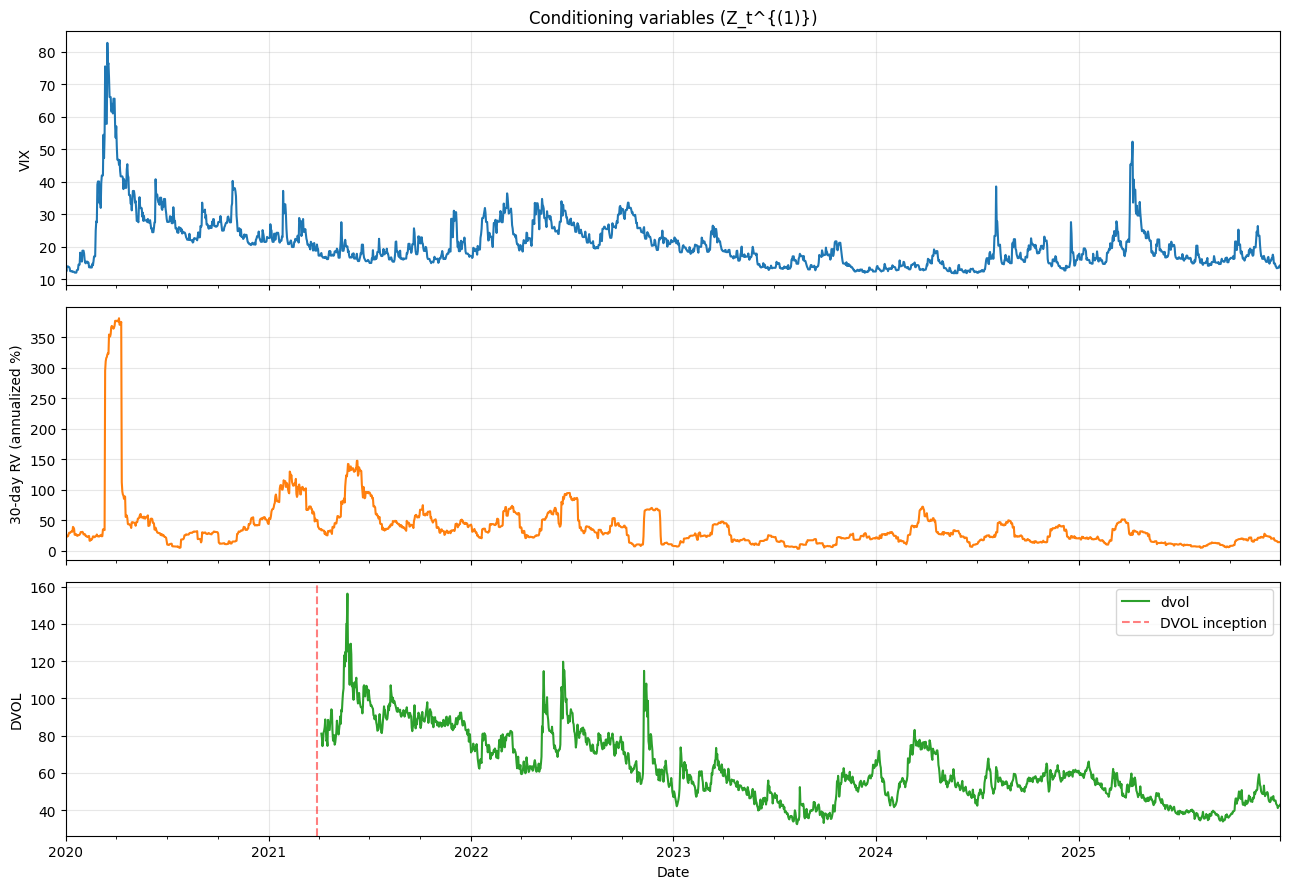

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
aux.set_index('date')['vix'].plot(ax=axes[0], color='C0')
axes[0].set_ylabel('VIX')
axes[0].set_title('Conditioning variables (Z_t^{(1)})')

(aux.set_index('date')['rv'] * 100).plot(ax=axes[1], color='C1')
axes[1].set_ylabel('30-day RV (annualized %)')

aux.set_index('date')['dvol'].plot(ax=axes[2], color='C2')
axes[2].set_ylabel('DVOL')
axes[2].set_xlabel('Date')
axes[2].axvline(pd.Timestamp('2021-03-29'), color='red', linestyle='--', alpha=0.5,
                label='DVOL inception')
axes[2].legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_conditioning_variables.png', dpi=150)
plt.show()

#### 6. Funding Rate Differential (HL - DER, Annualized)

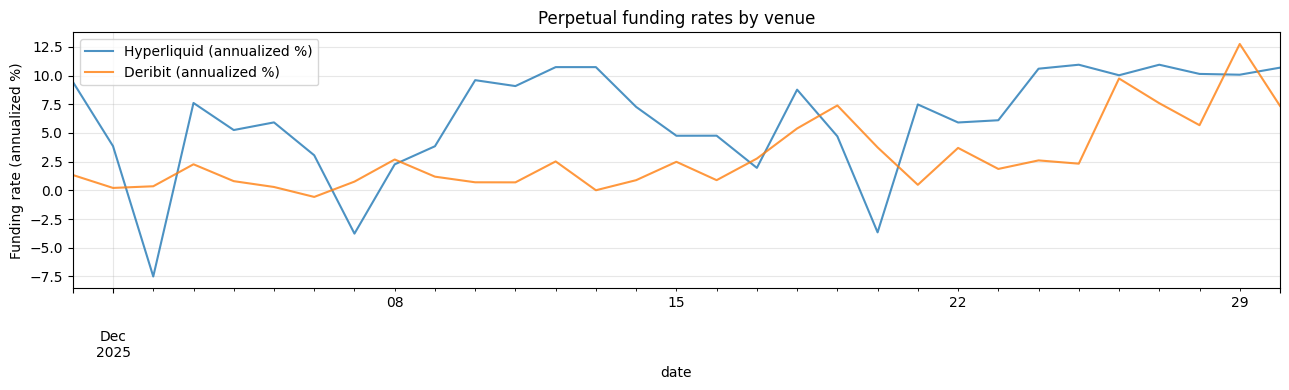

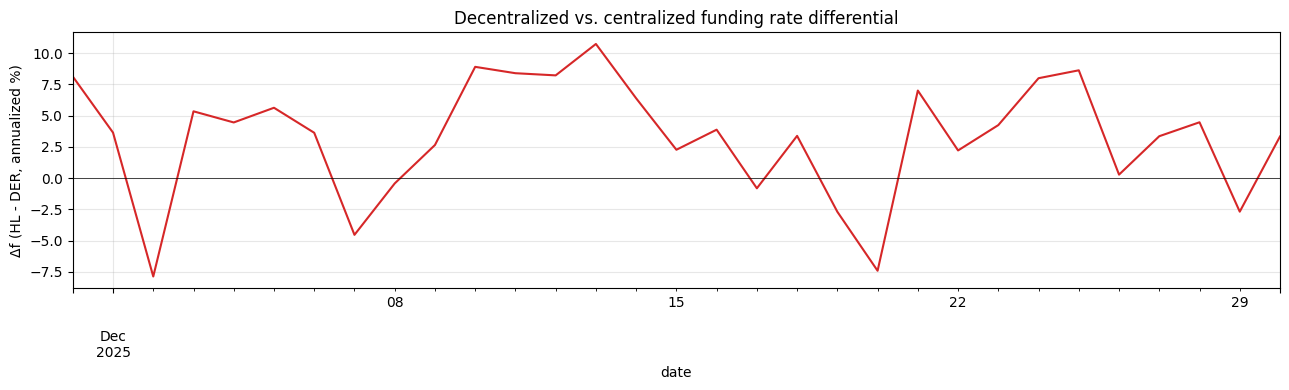


Funding rate statistics (annualized):
       funding_hl_annual  funding_der_annual  delta_f_hl_der
count          31.000000           31.000000       31.000000
mean            0.061850            0.029349        0.032501
std             0.046895            0.031766        0.046981
min            -0.075084           -0.005726       -0.078646
25%             0.042821            0.007325        0.012491
50%             0.072733            0.022719        0.036431
75%             0.100560            0.037220        0.066950
max             0.109500            0.127599        0.107320


In [10]:
if funding is not None:
    fig, ax = plt.subplots(figsize=(13, 4))
    (funding.set_index('date')['funding_hl_annual'] * 100).plot(
        ax=ax, label='Hyperliquid (annualized %)', alpha=0.8)
    (funding.set_index('date')['funding_der_annual'] * 100).plot(
        ax=ax, label='Deribit (annualized %)', alpha=0.8)
    ax.set_ylabel('Funding rate (annualized %)')
    ax.set_title('Perpetual funding rates by venue')
    ax.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'fig_funding_rates.png', dpi=150)
    plt.show()
    
    fig, ax = plt.subplots(figsize=(13, 4))
    (funding.set_index('date')['delta_f_hl_der'] * 100).plot(ax=ax, color='C3')
    ax.axhline(0, color='black', linewidth=0.5)
    ax.set_ylabel('Δf (HL - DER, annualized %)')
    ax.set_title('Decentralized vs. centralized funding rate differential')
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'fig_funding_differential.png', dpi=150)
    plt.show()
    
    print("\nFunding rate statistics (annualized):")
    print(funding[['funding_hl_annual', 'funding_der_annual', 'delta_f_hl_der']].describe())
else:
    print('Funding panel not yet available — run clean_hyperliquid.py first.')

#### 7. Thesis Data Summary Table

In [11]:
summary = pd.DataFrame({
    'CME': [
        len(cme),
        cme['date'].nunique(),
        cme['date'].min().date(),
        cme['date'].max().date(),
        round(daily_cme.median()),
        round(slices_cme['n'].median()),
        (cme['callput']=='C').sum(),
        (cme['callput']=='P').sum(),
    ],
    'Deribit': [
        len(der),
        der['date'].nunique(),
        der['date'].min().date(),
        der['date'].max().date(),
        round(daily_der.median()),
        round(slices_der['n'].median()),
        (der['callput']=='C').sum(),
        (der['callput']=='P').sum(),
    ],
}, index=['Cleaned rows', 'Trading days', 'Sample start', 'Sample end',
         'Median options/day', 'Median options/slice', 'Calls', 'Puts'])
print(summary)
summary.to_csv(PROJECT_ROOT / 'results' / 'tables' / 'data_summary.csv')

                             CME     Deribit
Cleaned rows               65598      327202
Trading days                 802        3105
Sample start          2020-01-13  2017-07-01
Sample end            2023-08-31  2025-12-30
Median options/day            82         100
Median options/slice          21          22
Calls                      34414      180908
Puts                       31184      146294
